# Thailand DDC 506 Disease Surveillance

This notebook demonstrates how to access notifiable disease surveillance data from the **Thailand Department of Disease Control (DDC)** 506 Disease Notification System.

**Data Source:**
- **DDC website:** https://ddc.moph.go.th/
- **System:** 506 Disease Notification (106 notifiable diseases)
- **Reports:** Weekly Epidemiological Surveillance Report (WESR)

**Coverage:**
- **Geographic:** 77 provinces + Bangkok
- **Temporal:** Annual (sample data curated from published DDC/WHO statistics)
- **Diseases:** Dengue, HIV/AIDS, malaria, influenza, tuberculosis, and 30 more

> **Note:** The ``data.go.th`` open data portal is currently geo-blocked.  
> This accessor uses representative sample data based on published national incidence rates.

**Requirements:**
```bash
pip install pandas matplotlib seaborn epidatasets
```

## 1. Setup and Imports

In [1]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Imports completed. {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Imports completed. 2026-06-22 16:08


## 2. Initialize the Accessor

In [2]:
from epidatasets.sources.thailand_ddc import ThailandDDCAccessor

ddc = ThailandDDCAccessor()

print(f"Source      : {ddc.source_name}")
print(f"Description : {ddc.source_description}")
print(f"Portal      : {ddc.source_url}")

Source      : thailand_ddc
Description : Notifiable disease surveillance data from the Thailand Department of Disease Control (DDC) 506 Disease Notification System, with representative sample data for key diseases including dengue, HIV/AIDS, influenza, malaria, and tuberculosis.
Portal      : https://ddc.moph.go.th/


In [3]:
countries = ddc.list_countries()
print(countries.to_string(index=False))

print(f"\nProvinces covered:")
provinces = ddc.list_provinces()
print(f"{len(provinces)} provinces")
provinces.head(10)

country_code country_name
          TH     Thailand

Provinces covered:
77 provinces


,province
0,Bangkok
1,Samut Prakan
2,Nonthaburi
3,Pathum Thani
4,Phra Nakhon Si Ayutthaya
5,Ang Thong
6,Lop Buri
7,Sing Buri
8,Chai Nat
9,Saraburi


## 3. National Disease Summary

Aggregate case counts across all 77 provinces for 35 notifiable diseases.

In [4]:
summary = ddc.get_national_summary()
display(summary.head(15))

,disease,cases
0,Acute Diarrhoea,1187866
1,Dengue Total,231161
2,Influenza,197974
3,Pneumonia,164791
4,Food Poisoning,131759
5,"Hand, Foot and Mouth Disease",98341
6,Tuberculosis (pulmonary),26380
7,Dengue Haemorrhagic Fever (DHF),26034
8,Syphilis,11820
9,Chikungunya,9934


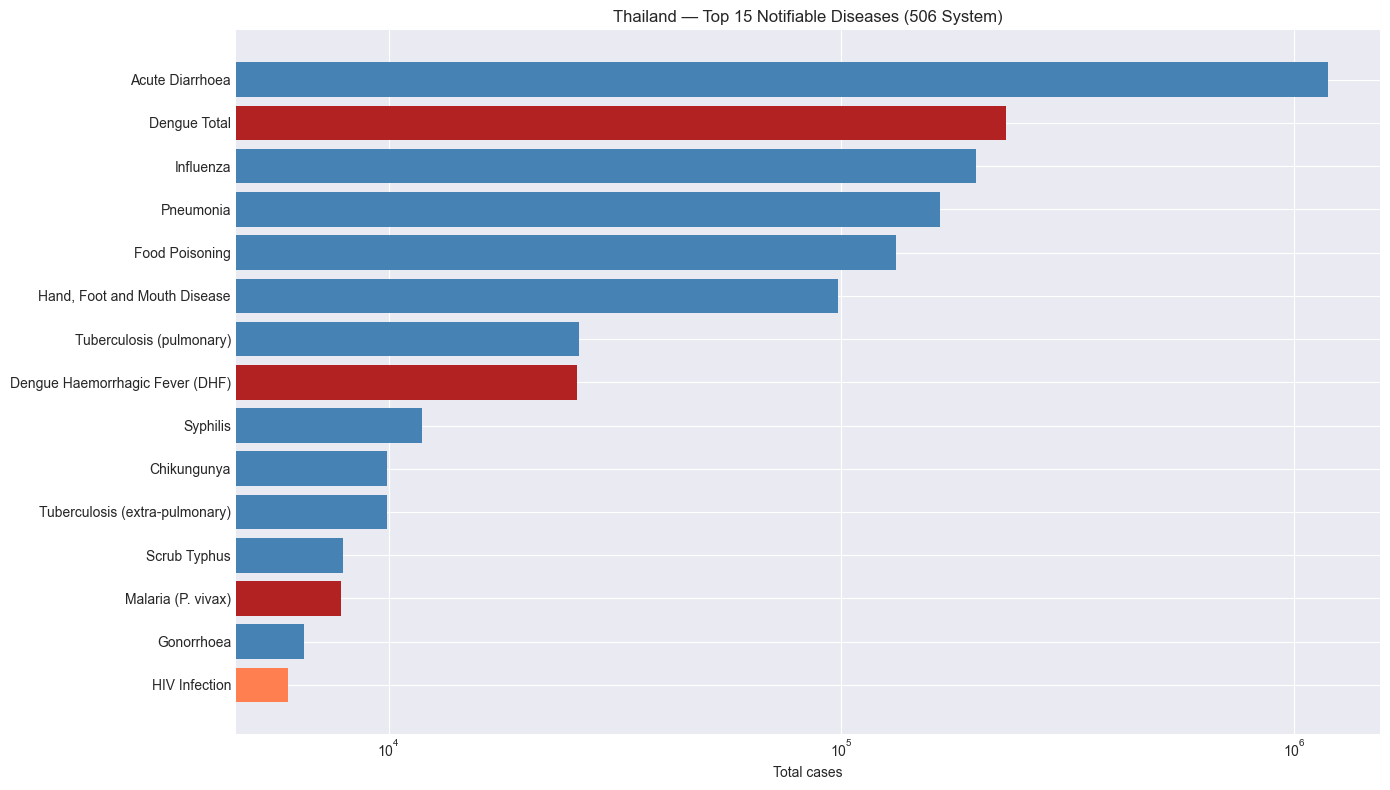

In [5]:
fig, ax = plt.subplots(figsize=(14, 8))
top = summary.head(15)
colors = ['firebrick' if 'dengue' in d.lower() or 'malaria' in d.lower()
          else 'coral' if 'hiv' in d.lower() or 'aids' in d.lower()
          else 'steelblue' for d in top['disease']]
ax.barh(top['disease'][::-1], top['cases'][::-1], color=colors[::-1])
ax.set_title('Thailand — Top 15 Notifiable Diseases (506 System)')
ax.set_xlabel('Total cases')
ax.set_xscale('log')
plt.tight_layout()
plt.show()

## 4. Vector-Borne Diseases

Dengue is one of Thailand's most significant vector-borne diseases, with 50 000–150 000 cases per year.  Malaria is concentrated in border provinces.

,disease,cases
0,Dengue Haemorrhagic Fever (DHF),26034
1,Dengue Shock Syndrome (DSS),3327
2,Dengue Total,231161


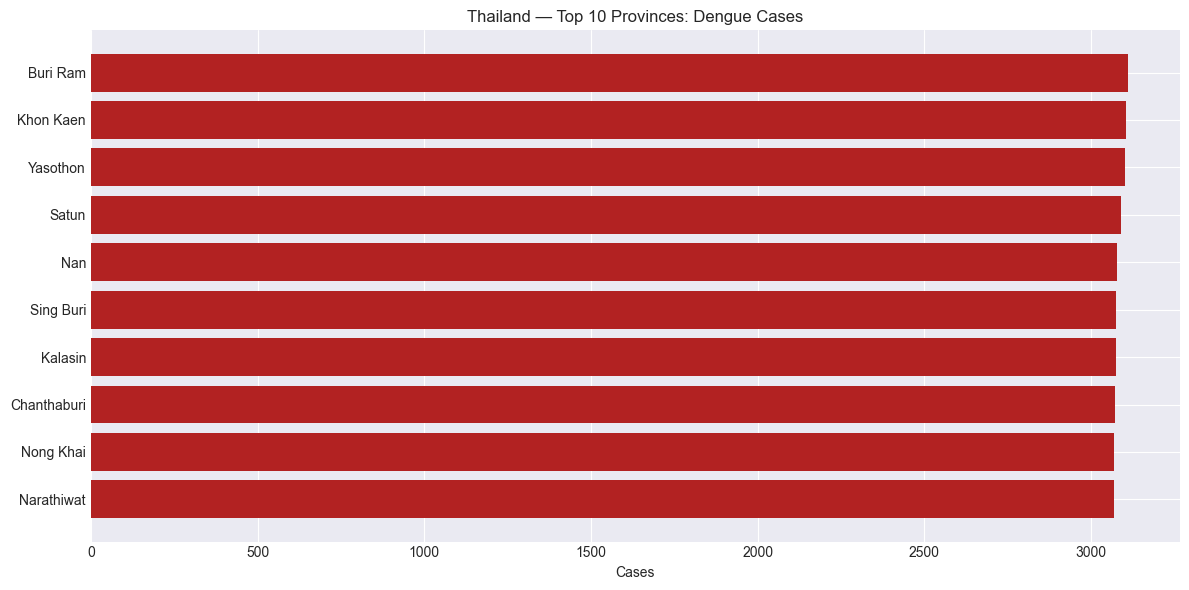

In [6]:
dengue = ddc.get_dengue_cases()
dengue_prov = dengue.groupby('disease', as_index=False)['cases'].sum()
display(dengue_prov)

# Top 10 provinces for dengue
dengue_total = dengue[dengue['disease'] == 'Dengue Total'].nlargest(10, 'cases')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(dengue_total['province'][::-1], dengue_total['cases'][::-1], color='firebrick')
ax.set_title('Thailand — Top 10 Provinces: Dengue Cases')
ax.set_xlabel('Cases')
plt.tight_layout()
plt.show()

### Malaria by species

Thailand has dramatically reduced malaria, with most remaining cases in the border areas with Myanmar, Cambodia, and Laos.

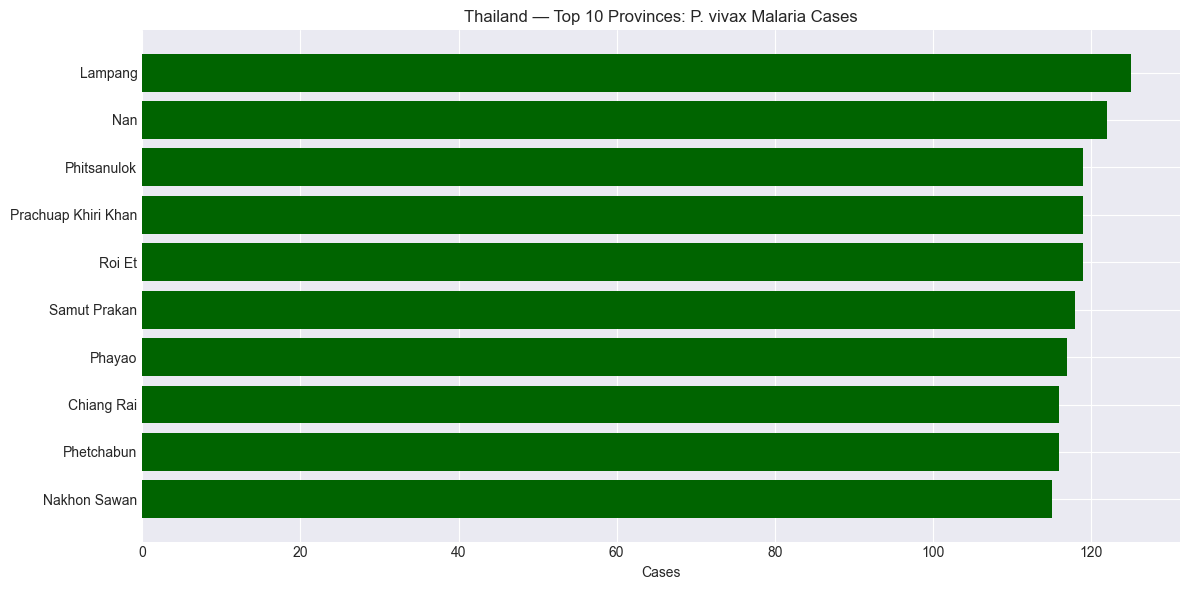

In [7]:
malaria = ddc.get_malaria_cases()
malaria_prov = malaria.groupby(['disease', 'province'], as_index=False)['cases'].sum()
malaria_top = malaria_prov[malaria_prov['disease'] == 'Malaria (P. vivax)'].nlargest(10, 'cases')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(malaria_top['province'][::-1], malaria_top['cases'][::-1], color='darkgreen')
ax.set_title('Thailand — Top 10 Provinces: P. vivax Malaria Cases')
ax.set_xlabel('Cases')
plt.tight_layout()
plt.show()

## 5. HIV/AIDS by Province

Thailand has one of the most successful HIV programmes in Asia, but certain provinces still bear a higher burden.

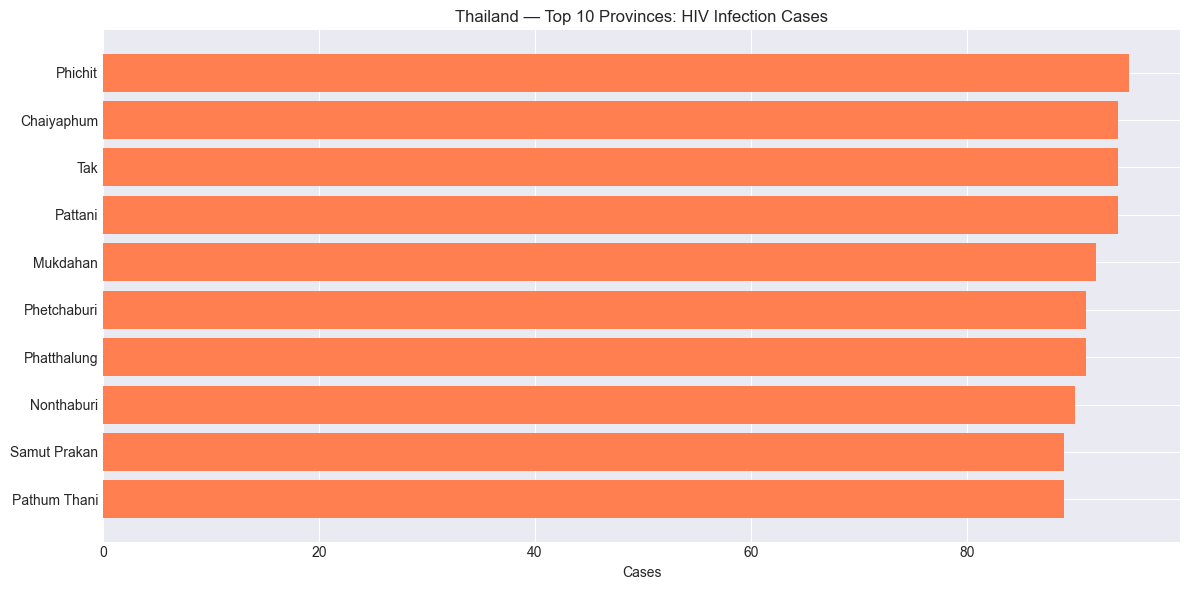

In [8]:
hiv = ddc.get_hiv_cases()
hiv_prov = hiv[hiv['disease'] == 'HIV Infection'].nlargest(10, 'cases')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(hiv_prov['province'][::-1], hiv_prov['cases'][::-1], color='coral')
ax.set_title('Thailand — Top 10 Provinces: HIV Infection Cases')
ax.set_xlabel('Cases')
plt.tight_layout()
plt.show()

## 6. Provincial Overview

Total burden across all notifiable diseases, by province.

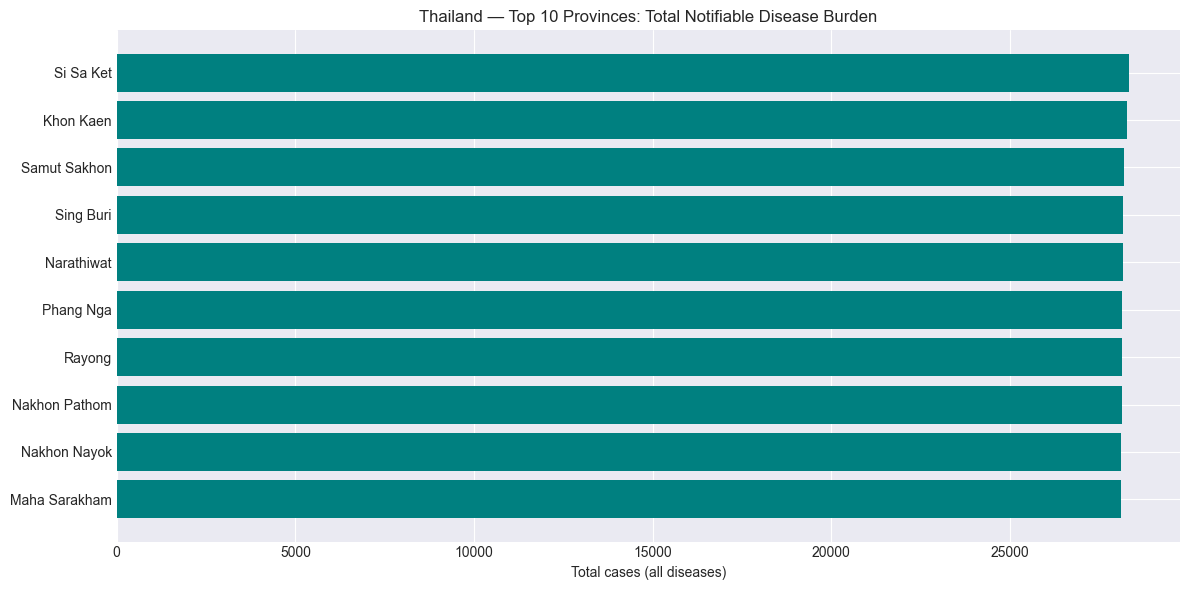

In [9]:
prov_summary = ddc.get_provincial_summary()
top_provinces = prov_summary.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_provinces['province'][::-1], top_provinces['cases'][::-1], color='teal')
ax.set_title('Thailand — Top 10 Provinces: Total Notifiable Disease Burden')
ax.set_xlabel('Total cases (all diseases)')
plt.tight_layout()
plt.show()

## 7. Summary

| Method | Description |
|--------|-------------|
| `list_provinces()` | 77 provinces + Bangkok |
| `list_diseases()` | 35 notifiable diseases (506 system) |
| `get_surveillance_data(year, province, disease)` | Full surveillance data |
| `get_dengue_cases(year, province)` | Dengue/DHF/DSS by province |
| `get_hiv_cases(year, province)` | HIV/AIDS by province |
| `get_malaria_cases(year, province)` | Malaria by species and province |
| `get_national_summary(year)` | National disease totals, ranked |
| `get_provincial_summary(disease, year)` | Province-level totals |

**Related notebooks:**
- [Malaysia MOH Health Data](28_Malaysia_MOH_Health_Data.ipynb) — similar SE Asian MOH data.
- [Singapore NEA Dengue](27_Singapore_NEA_Dengue_Data.ipynb) — for dengue-specific comparison.
- [WHO Global Health Data](02_who_global_health_data.ipynb) — cross-country comparisons.